In [2]:
import spotipy
from spotipy.oauth2 import SpotifyOAuth
from getpass import getpass

recco_base = "https://api.reccobeats.com/v1/"
recco_payload = {}
recco_headers = {
    'Accept': 'application/json'
}

CLIENT_ID = getpass("Enter client ID: ")
CLIENT_SECRET = getpass("Enter client secret: ")
REDIRECT_URI = getpass("Enter redirect URI: ")

auth_manager = SpotifyOAuth(
        client_id=CLIENT_ID,
        client_secret=CLIENT_SECRET,
        redirect_uri=REDIRECT_URI,
        scope='user-top-read'
    )
sp = spotipy.Spotify(auth_manager=auth_manager)

In [4]:
import requests, json, csv
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def get_audio_features(id):
    url = "https://api.reccobeats.com/v1/audio-features?ids=" + id
    response = requests.get(url, headers=recco_headers, data=recco_payload)
    if response.status_code != 200:
        raise Exception("Error getting audio features from ReccoBeats:", response.status_code, response.reason, response.content)
    audio_features = json.loads(str(response.content, 'utf-8'))['content']
    if audio_features == []:
        return
    return audio_features[0]

def get_album_popularity(id):
    url = "https://api.reccobeats.com/v1/album?ids=" + id
    response = requests.get(url, headers=recco_headers, data=recco_payload)
    if response.status_code != 200:
        raise Exception("Error getting album from ReccoBeats:", response.status_code, response.reason, response.content)
    popularity = json.loads(str(response.content, 'utf-8'))['content']
    if popularity == []:
        return 0
    return popularity[0]['popularity']

In [5]:
time_range = 'short_term'
track_limit = 5

In [6]:
top_artists = sp.current_user_top_artists(limit=track_limit, time_range=time_range)['items']
data = [['Artist', 'Image URL']]

for artist in top_artists:
    data.append([artist['name'], artist['images'][0]['url']])
    print(artist['name'], artist['images'][0]['url'])

with open('data/top_artists.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(data)

STOMACH BOOK https://i.scdn.co/image/ab6761610000e5eb8d348e0c0af5b63a1d189c98
Darkthrone https://i.scdn.co/image/ab6761610000e5eb79320f5cf422d8a8e98836c4
Pissgrave https://i.scdn.co/image/ab67616d0000b273c413b8576f53d972f17fecea
Sleep https://i.scdn.co/image/ab6761610000e5ebb36931f79c04ab8418391515
Electric Wizard https://i.scdn.co/image/bee61096977bc59279c1a3145f4e32df6a5d7b96


In [ ]:
avg_info = {
    'acousticness': 0,
    'danceability': 0,
    'energy': 0,
    'instrumentalness': 0,
    'loudness': 0,
    'tempo': 0,
    'valence': 0,
    'duration_ms': 0,
    'popularity': 0,
}
years = []
artist_appearances = {}

total_tracks_with_data = 0
albums_with_popularity_data = 0
top_tracks = sp.current_user_top_tracks(limit=track_limit, time_range=time_range)['items']
saved_tracks = sp.current_user_saved_tracks(limit=track_limit)['items']
all_tracks = []
top_track_artist_appearances = {}

for track_item in saved_tracks:
    all_tracks.append(track_item['track'])
for track in top_tracks:
    all_tracks.append(track)
    artist = track['artists'][0]['name']
    if artist in top_track_artist_appearances:
        top_track_artist_appearances[artist] += 1
    else:
        top_track_artist_appearances[artist] = 1

for track in all_tracks:
    audio_features = get_audio_features(track['id'])
    if audio_features != None:
        total_tracks_with_data += 1
        avg_info['duration_ms'] += track['duration_ms']
        years.append(int(track['album']['release_date'][:4]))
        for audio_feature in audio_features:
            if audio_feature in avg_info:
                avg_info[audio_feature] += audio_features[audio_feature]
    
    popularity = get_album_popularity(track['album']['id'])
    avg_info['popularity'] += popularity
    albums_with_popularity_data += 1 if popularity != 0 else 0

    artist = track['artists'][0]['name']
    if artist in artist_appearances:
        artist_appearances[artist] += 1
    else:
        artist_appearances[artist] = 1

for info in avg_info:
    if info == 'popularity':
        continue
    avg_info[info] /= total_tracks_with_data
avg_info['popularity'] /= albums_with_popularity_data

with open('data/avg_data.csv', 'w', newline='') as file:
    writer = csv.DictWriter(file, avg_info.keys())
    writer.writerows(avg_info)

with open('data/years_listened.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(years)

#with open('data/artist_appearances.csv', 'w', newline='') as file:
#    writer = csv.DictWriter(file)
#    writer.writerows(artist_appearances)

In [ ]:
avg_info = {
    'acousticness': 0,
    'danceability': 0,
    'energy': 0,
    'instrumentalness': 0,
    'loudness': 0,
    'tempo': 0,
    'valence': 0,
    'duration_ms': 0,
    'popularity': 0,
    'years': [],
    'artist_appearances': {}
}
total_tracks_with_data = 0
albums_with_popularity_data = 0
top_tracks = sp.current_user_top_tracks(limit=track_limit, time_range=time_range)['items']
saved_tracks = sp.current_user_saved_tracks(limit=track_limit)['items']
all_tracks = []
top_track_artist_appearances = {}

for track_item in saved_tracks:
    all_tracks.append(track_item['track'])
for track in top_tracks:
    all_tracks.append(track)
    artist = track['artists'][0]['name']
    if artist in top_track_artist_appearances:
        top_track_artist_appearances[artist] += 1
    else:
        top_track_artist_appearances[artist] = 1

for track in all_tracks:
    audio_features = get_audio_features(track['id'])
    if audio_features != None:
        total_tracks_with_data += 1
        avg_info['duration_ms'] += track['duration_ms']
        avg_info['years'].append(int(track['album']['release_date'][:4]))
        for audio_feature in audio_features:
            if audio_feature in avg_info:
                avg_info[audio_feature] += audio_features[audio_feature]
    
    popularity = get_album_popularity(track['album']['id'])
    avg_info['popularity'] += popularity
    albums_with_popularity_data += 1 if popularity != 0 else 0

    artist = track['artists'][0]['name']
    if artist in avg_info['artist_appearances']:
        avg_info['artist_appearances'][artist] += 1
    else:
        avg_info['artist_appearances'][artist] = 1

for info in avg_info:
    if info == 'popularity':
        continue
    if isinstance(avg_info[info], float) or isinstance(avg_info[info], int):
        avg_info[info] /= total_tracks_with_data
avg_info['popularity'] /= albums_with_popularity_data

print(avg_info)

{'acousticness': 0.11174723210526316, 'danceability': 0.30610526315789477, 'energy': 0.9227894736842106, 'instrumentalness': 0.3464215789473684, 'loudness': -4.518526315789473, 'tempo': 118.91663157894737, 'valence': 0.2866473684210526, 'duration_ms': 291411.1052631579, 'popularity': 48.45, 'years': [2024, 2024, 2024, 2024, 2021, 1986, 1992, 1992, 1997, 2021, 2021, 1993, 1993, 2021, 2021, 1993, 2024, 2021, 1994], 'artist_appearances': {'STOMACH BOOK': 11, 'Uncle Acid & The Deadbeats': 1, 'Megadeth': 1, 'Pantera': 2, 'Deftones': 1, 'Darkthrone': 3, 'Sleep': 1}}


In [12]:
responses = {}

acousticness = avg_info['acousticness']
if acousticness < 0.5:
    responses['acousticness'] = "You seem to like music with electronic, digital, or amplified elements the best!"
elif acousticness < 0.8:
    responses['acousticness'] = "Your music seems to be in between electronic/digital and acoustic"
else:
    responses['acousticness'] = "Seems you have a preference for purely acoustic music!"

danceability = avg_info['danceability']
if danceability < 0.4:
    responses['danceability'] = "Your songs seems hard to dance to..."
elif danceability < 0.65:
    responses['danceability'] = "If you try very hard, you <i>might</i> be able to dance to your songs..."
elif danceability < 0.8:
    responses['danceability'] = "Your songs are great to dance to!"
else:
    responses['danceability'] = "Your songs were made to be danced to!"

energy = avg_info['energy']
if energy < 0.3:
    responses['energy'] = "You don't seem to be the energetic type"
elif energy < 0.55:
    responses['energy'] = "There's slight energy in the music you listen to..."
elif energy < 0.8:
    responses['energy'] = "Your music is fairly energetic!"
else:
    responses['energy'] = "Your music is very energetic!"

instrumentalness = avg_info['instrumentalness']
if instrumentalness < 0.3:
    responses['instrumentalness'] = "Either you're fan of clear rap or big on singing. You love to be able to hear vocals!"
elif instrumentalness < 0.5:
    responses['instrumentalness'] = "Most of your favorite vocalists don't seem to be speaking clearly enough, are shouting or screaming, or are buried under the instruments"
elif instrumentalness < 0.7:
    responses['instrumentalness'] = "Either most of your favorite vocalists are incomprehensible or you prefer to listen to instrumental music"
else:
    responses['instrumentalness'] = "You much prefer instrumental music. Instruments over the voice!"

loudness = avg_info['loudness']
if loudness < -25:
    responses['loudness'] = "Your music is very quiet... Perhaps a fan of ambient or calming music?"
elif loudness < -15:
    responses['loudness'] = "Your music is quiet quiet. You love calming music, but not pure ambience"
elif loudness < -10:
    responses['loudness'] = "Your music is at a fair volume"
elif loudness < -7:
    responses['loudness'] = "You like your music fairly loud!"
elif loudness < -5:
    responses['loudness'] = "You like it loud!! Most likely a rock, metal, or EDM fan!"
else:
    responses['loudness'] = "You like it really loud!!! Most definitely a fan of metal, hardcore EDM, or maybe even noise music!"

tempo = avg_info['tempo']
if tempo < 60:
    responses['tempo'] = "Most of your top songs are slower than a clock ticking!"
elif tempo < 109:
    responses['tempo'] = "Your top songs are fairly slow"
elif tempo < 120:
    responses['tempo'] = "Your top songs are at a fairly normal tempo"
elif tempo < 158:
    responses['tempo'] = "Your top songs are fairly upbeat and fast!"
elif tempo < 180:
    responses['tempo'] = "You like your songs quite fast and lively!"
else:
    responses['tempo'] = "You like your songs really fast!"

time_range_responses = {
    "short_term": "The past week has been ",
    "medium_term": "The past 6 months have been ",
    "long_term": "The past year has been "
}
time_range_response = time_range_responses[time_range]
valence = avg_info['valence']
if valence < 0.25:
    responses['valence'] = time_range_response + "very unkind to you. Whatever emotions your top songs have, they definitely aren't happiness"
elif valence < 0.5:
    responses['valence'] = time_range_response + "alright. Your top songs don't seem incredibly happy"
elif valence < 0.75:
    responses['valence'] = time_range_response + "average, it seems. Your top songs don't seem too sad or dark, but not incredibly happy"
else:
    responses['valence'] = time_range_response + "pretty good! Your top songs seem to be pretty happy and positive"

duration_m = avg_info['duration_ms'] / 60000
if duration_m < 1.5:
    responses['duration_m'] = "Most of your favorite tracks aren't even a minute long... You are absolutely a grindcore fan or are listening to sound effects."
elif duration_m < 4.5:
    responses['duration_m'] = "Nothing much to say here, this is a fairly normal length of a song!"
elif duration_m < 8:
    responses['duration_m'] = "You like long songs, but not too long, I see"
elif duration_m < 12:
    responses['duration_m'] = "Your in for the long run!"
else:
    responses['duration_m'] = "Your music must send you in a trance if they go on for this long..."

popularity = avg_info['popularity']

eras = {
    (0, 1919): 0,
    (1920, 1949): 0,
    (1950, 1969): 0,
    (1970, 1979): 0,
    (1980, 1989): 0,
    (1990, 1999): 0,
    (2000, 2009): 0,
    (2010, 2015): 0,
    (2016, 2019): 0,
    (2020, 2021): 0,
    (2022, 2026): 0
}
eras_responses = {
    (0, 1919): "You are a dinosaur.",
    (1920, 1949): "You are a great grandparent. Did you live through the Great Depression or WW1?",
    (1950, 1969): "You have an old soul",
    (1970, 1979): "You have a 70s soul",
    (1980, 1989): "You have an 80s soul",
    (1990, 1999): "You have a 90s soul",
    (2000, 2009): "You have a 2000s soul",
    (2010, 2015): "You yearn for the early 2000s",
    (2016, 2019): "You yearn for the late 2000s",
    (2020, 2021): "You are quite fond of pandemic music",
    (2022, 2026): "You're in for the new! Your music taste is quite new"
}
for year in avg_info['years']:
    for era in eras:
        if year >= era[0] and year <= era[1]:
            eras[era] += 1
most_listened_era = max(eras, key=eras.get)
responses['years'] = eras_responses[most_listened_era]

for response in responses:
    print(responses[response])

You seem to like music with electronic, digital, or amplified elements the best!
Your songs seems hard to dance to...
Your music is very energetic!
Most of your favorite vocalists don't seem to be speaking clearly enough, are shouting or screaming, or are buried under the instruments
You like it loud!! Most likely a rock, metal, or EDM fan!
Your top songs are at a fairly normal tempo
The past 6 months have been very unkind to you. Whatever emotions your top songs have, they definitely aren't happiness
You like long songs, but not too long, I see
You have a 90s soul


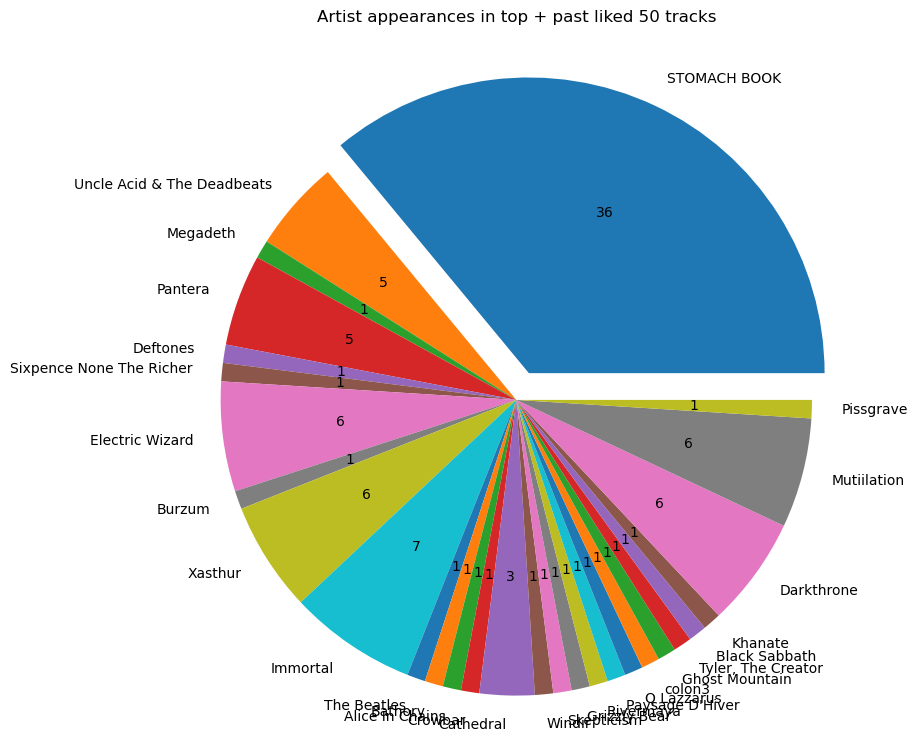

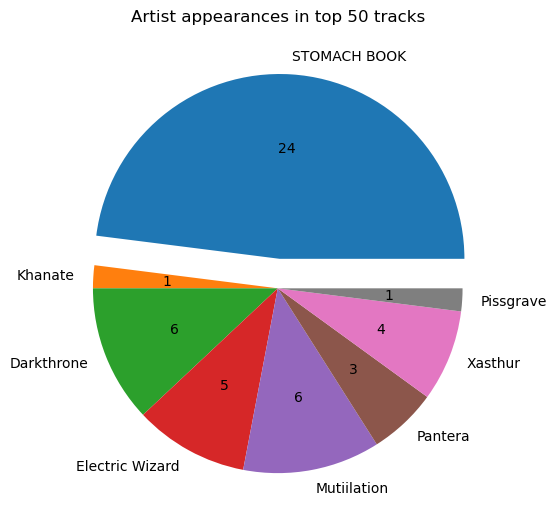

In [11]:
labels = []
sizes = []
def percent_to_int(percent):
    return int(np.round(percent / 100 * sum(sizes), 0))

for artist in avg_info['artist_appearances']:
    sizes.append(avg_info['artist_appearances'][artist])
    labels.append(artist)
greatest_slice = max(sizes)
max_i = sizes.index(greatest_slice)
explode_val = tuple([0 if i != max_i else 0.2 for i in range(len(sizes))])
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct=percent_to_int, explode=explode_val, radius=2)
ax.set_title('Artist appearances in top + past liked ' + str(track_limit) + ' tracks', y=1.5)
plt.savefig('chart1.png')
plt.show()

labels = []
sizes = []
for artist in top_track_artist_appearances:
    sizes.append(top_track_artist_appearances[artist])
    labels.append(artist)
greatest_slice = max(sizes)
max_i = sizes.index(greatest_slice)
explode_val = tuple([0 if i != max_i else 0.2 for i in range(len(sizes))])
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct=percent_to_int, explode=explode_val, radius=1.25)
ax.set_title('Artist appearances in top ' + str(track_limit) + ' tracks', y=1.2)
plt.savefig('chart2.png')
plt.show()